In [1]:
import pandas as pd
import numpy as np


from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [2]:
import os
print(os.getcwd())

C:\Users\Analysis_VM\Desktop\Ransomware_Project\notebooks


In [3]:
df = pd.read_csv("../data/pe_features(New_v2).csv")
df.head()

,sha256,file_name,family,file_size,num_sections,many_sections,size_of_image,size_of_code,entry_point,num_imports,...,avg_entropy,max_entropy,min_entropy,has_crypto,has_bcrypt,has_file_ops,has_version_info,has_debug,wx_sections,label
0,fac81bcdcb6ccf8505dfa44a9b4756a50e67b89f8c8fcf...,3uTools.exe,benign,13675880,6,0,13672448,9740288,8547568,4313,...,5.135459,6.374358,2.818603,0,0,1,1,1,0,0
1,8fdeb6c13162c9398e97b66c4f0a780c1e270e300a637e...,3uViewer.exe,benign,989928,6,0,978944,54784,51084,693,...,4.562831,6.085465,3.433966,0,0,0,1,1,0,0
2,7faad7057f2f88a431803c32fb7d272199bba89de3dc60...,7z.exe,benign,492608,6,0,491520,318976,319776,127,...,4.300758,6.285946,1.232928,0,0,1,1,0,0,0
3,0a038cc8dc46b6d50245c6951dc238fba63654a0cb3d23...,CrashReport.exe,benign,971992,5,0,970752,561664,383673,279,...,5.502765,6.607745,4.518242,0,0,0,0,0,0,0
4,b58aeb18d26cfd9b63c9ccfa0ebfe40d9ab7a01b4c9856...,InfInstallerx64.exe,benign,217152,6,0,221184,135680,56616,107,...,4.909627,6.413611,3.484201,0,0,0,0,1,0,0


In [4]:
df.shape

(1649, 21)

In [5]:
df["label"].value_counts()

label
0    936
1    713
Name: count, dtype: int64

In [6]:
print(df.columns)

Index(['sha256', 'file_name', 'family', 'file_size', 'num_sections',
       'many_sections', 'size_of_image', 'size_of_code', 'entry_point',
       'num_imports', 'num_dlls', 'avg_entropy', 'max_entropy', 'min_entropy',
       'has_crypto', 'has_bcrypt', 'has_file_ops', 'has_version_info',
       'has_debug', 'wx_sections', 'label'],
      dtype='str')


In [7]:
df = df.drop(["sha256","file_name","family"], axis=1)
df.head()

,file_size,num_sections,many_sections,size_of_image,size_of_code,entry_point,num_imports,num_dlls,avg_entropy,max_entropy,min_entropy,has_crypto,has_bcrypt,has_file_ops,has_version_info,has_debug,wx_sections,label
0,13675880,6,0,13672448,9740288,8547568,4313,51,5.135459,6.374358,2.818603,0,0,1,1,1,0,0
1,989928,6,0,978944,54784,51084,693,22,4.562831,6.085465,3.433966,0,0,0,1,1,0,0
2,492608,6,0,491520,318976,319776,127,5,4.300758,6.285946,1.232928,0,0,1,1,0,0,0
3,971992,5,0,970752,561664,383673,279,12,5.502765,6.607745,4.518242,0,0,0,0,0,0,0
4,217152,6,0,221184,135680,56616,107,5,4.909627,6.413611,3.484201,0,0,0,0,1,0,0


In [8]:
X = df.drop("label", axis=1)
y = df["label"]

In [9]:
# ============================================
# CELL: Train/Test Split
# Purpose:
# Split dataset while preserving class distribution
# ============================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("[INFO] Train/Test split completed")
print(f"[INFO] Train samples: {len(X_train)}")
print(f"[INFO] Test samples: {len(X_test)}")

[INFO] Train/Test split completed
[INFO] Train samples: 1319
[INFO] Test samples: 330


In [10]:
# ============================================
# CELL: Feature Scaling
# Purpose:
# Scale numerical features for distance-based models
# ============================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("[INFO] Scaling completed")

[INFO] Scaling completed


In [11]:
#Compare between models 

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score

models = { 
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=3000)
}

In [12]:
# ============================================
# CELL: Train ML Models
# Purpose:
# Train and evaluate multiple ML algorithms
# ============================================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

NEEDS_SCALING = {
    "Logistic Regression",
    "KNN"
}

results = {}

for name, model in models.items():

    print(f"\n[INFO] Training: {name}")

    if name in NEEDS_SCALING:

        model.fit(X_train_scaled, y_train)

        pred = model.predict(X_test_scaled)

        prob = model.predict_proba(X_test_scaled)[:, 1]

    else:

        model.fit(X_train, y_train)

        pred = model.predict(X_test)

        prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    roc_auc = roc_auc_score(y_test, prob)

    results[name] = {
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc
    }

    print(classification_report(y_test, pred))

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")


[INFO] Training: Random Forest
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       187
           1       0.99      0.95      0.97       143

    accuracy                           0.97       330
   macro avg       0.97      0.97      0.97       330
weighted avg       0.97      0.97      0.97       330

Accuracy : 0.9727
Precision: 0.9855
Recall   : 0.9510
F1 Score : 0.9680
ROC-AUC  : 0.9969

[INFO] Training: Decision Tree
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       187
           1       0.94      0.94      0.94       143

    accuracy                           0.95       330
   macro avg       0.95      0.95      0.95       330
weighted avg       0.95      0.95      0.95       330

Accuracy : 0.9515
Precision: 0.9441
Recall   : 0.9441
F1 Score : 0.9441
ROC-AUC  : 0.9506

[INFO] Training: KNN
              precision    recall  f1-score   support

           0       0.96  

In [13]:
# ============================================
# CELL: Cross Validation
# Purpose:
# Measure model stability using Stratified K-Fold
# ============================================

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=cv,
    scoring="f1"
)

print("[INFO] Cross Validation Results")
print(f"[INFO] Scores: {scores}")
print(f"[INFO] Mean F1: {scores.mean():.4f}")
print(f"[INFO] Std F1 : {scores.std():.4f}")

[INFO] Cross Validation Results
[INFO] Scores: [0.98939929 0.97183099 0.96750903 0.98954704 0.97163121]
[INFO] Mean F1: 0.9780
[INFO] Std F1 : 0.0095


In [14]:
import joblib
from sklearn.ensemble import RandomForestClassifier

final_model = RandomForestClassifier(n_estimators=200, random_state=42)
final_model.fit(X_train, y_train)

FEATURE_COLUMNS = X.columns.tolist()

joblib.dump(
    {
        "model": final_model,
        "features": FEATURE_COLUMNS
    },
    "model.pkl"
)

print("[SUCCESS] Model saved")


[SUCCESS] Model saved


In [15]:
# ============================================
# CELL: Save Feature Scaler
# Purpose:
# Save trained scaler for inference
# ============================================

import joblib

joblib.dump(
    scaler,
    "scaler.pkl"
)

print("[SUCCESS] Scaler saved")

[SUCCESS] Scaler saved


In [23]:
# ============================================
# CELL: Prediction Feature Extraction
# Purpose:
# Extract EXACT SAME features used during training
# ============================================

import pefile
import numpy as np
import math
import os

from collections import Counter


def calculate_entropy(data):

    if not data:
        return 0.0

    counter = Counter(data)

    length = len(data)

    entropy = 0

    for count in counter.values():

        p = count / length

        entropy -= p * math.log2(p)

    return entropy


def extract_features(file_path):
    try:
        pe = pefile.PE(file_path, fast_load=True)
        pe.parse_data_directories(directories=[
            pefile.DIRECTORY_ENTRY['IMAGE_DIRECTORY_ENTRY_IMPORT'],
            pefile.DIRECTORY_ENTRY['IMAGE_DIRECTORY_ENTRY_RESOURCE'],
        ])

        file_size     = os.path.getsize(file_path)
        num_sections  = pe.FILE_HEADER.NumberOfSections
        many_sections = int(num_sections > 6)
        size_of_image = pe.OPTIONAL_HEADER.SizeOfImage
        size_of_code  = pe.OPTIONAL_HEADER.SizeOfCode
        entry_point   = pe.OPTIONAL_HEADER.AddressOfEntryPoint

        num_imports = 0
        num_dlls    = 0
        has_crypto  = 0
        has_bcrypt  = 0
        has_file_ops = 0

        CRYPTO_APIS = {
            "CryptEncrypt","CryptDecrypt","CryptGenKey","CryptAcquireContext",
            "BCryptEncrypt","BCryptDecrypt",
            "BCryptGenerateSymmetricKey","BCryptOpenAlgorithmProvider",
        }
        FILE_OPS = {"MoveFileExW", "DeleteFileW"}

        if hasattr(pe, "DIRECTORY_ENTRY_IMPORT"):
            num_dlls = len(pe.DIRECTORY_ENTRY_IMPORT)
            for entry in pe.DIRECTORY_ENTRY_IMPORT:
                num_imports += len(entry.imports)
                for imp in entry.imports:
                    if imp.name:
                        name = imp.name.decode(errors="ignore")
                        if name in CRYPTO_APIS:
                            has_crypto = 1
                        if name.startswith("BCrypt"):
                            has_bcrypt = 1
                        if name in FILE_OPS:
                            has_file_ops = 1

        entropies   = [calculate_entropy(s.get_data()) for s in pe.sections]
        avg_entropy = np.mean(entropies) if entropies else 0.0
        max_entropy = np.max(entropies)  if entropies else 0.0
        min_entropy = np.min(entropies)  if entropies else 0.0

        # New features
        has_version_info = 0
        if hasattr(pe, 'DIRECTORY_ENTRY_RESOURCE'):
            for res_type in pe.DIRECTORY_ENTRY_RESOURCE.entries:
                if hasattr(res_type, 'id') and res_type.id == 16:
                    has_version_info = 1
                    break

        try:
            has_debug = int(pe.OPTIONAL_HEADER.DATA_DIRECTORY[6].Size > 0)
        except Exception:
            has_debug = 0

        wx_sections = sum(
            1 for s in pe.sections
            if (s.Characteristics & 0x20000000) and
               (s.Characteristics & 0x80000000)
        )

        pe.close()

        return np.array([
            file_size, num_sections, many_sections,
            size_of_image, size_of_code, entry_point,
            num_imports, num_dlls,
            avg_entropy, max_entropy, min_entropy,
            has_crypto, has_bcrypt, has_file_ops,
            has_version_info, has_debug, wx_sections
        ]).reshape(1, -1)

    except Exception as e:
        print("Error:", e)
        return None

In [24]:
#Predection

import joblib
import numpy as np
import pandas as pd

def predict(file_path):

    saved = joblib.load("model.pkl")

    model = saved["model"]

    features = extract_features(file_path)

    if features is None:

        return "Invalid PE File"

    features = pd.DataFrame(

        features,

        columns=FEATURE_COLUMNS

    )

    prediction = model.predict(features)[0]

    prob = model.predict_proba(features)[0]

    confidence = max(prob) * 100

    if prediction == 1:

        return f"RANSOMWARE ({confidence:.2f}%)"

    else:

        print("Probabilities:", prob)

        return f"BENIGN ({confidence:.2f}%)"

In [25]:
# ============================================
# CELL: Inference Test
# Purpose:
# Test model on unseen PE files
# ============================================

test_files = [

    "../test_samples/notepad++.exe", # Benign file

    "../test_samples/12bba7161d07efcb1b14d30054901ac9ffe5202972437b0c47c88d71e45c7176.exe", # Ransomware file

    "../test_samples/obs64.exe" # Packed_bengin file

]

for file in test_files:

    print("\n" + "=" * 50)

    print("File:", file)

    result = predict(file)

    print("Prediction:", result)


File: ../test_samples/notepad++.exe
Probabilities: [1. 0.]
Prediction: BENIGN (100.00%)

File: ../test_samples/12bba7161d07efcb1b14d30054901ac9ffe5202972437b0c47c88d71e45c7176.exe
Prediction: RANSOMWARE (88.00%)

File: ../test_samples/obs64.exe
Probabilities: [0.985 0.015]
Prediction: BENIGN (98.50%)


In [26]:
# ============================================
# CELL: Feature Importance
# Purpose:
# Understand which features affect predictions most
# ============================================

import pandas as pd

importance_df = pd.DataFrame({

    "Feature": FEATURE_COLUMNS,

    "Importance": final_model.feature_importances_

})

importance_df = importance_df.sort_values(

    by="Importance",

    ascending=False

)

print(importance_df)

             Feature  Importance
14  has_version_info    0.368146
15         has_debug    0.084335
9        max_entropy    0.078333
7           num_dlls    0.071005
6        num_imports    0.060267
5        entry_point    0.058307
8        avg_entropy    0.053875
10       min_entropy    0.051947
3      size_of_image    0.051904
0          file_size    0.046947
4       size_of_code    0.032888
1       num_sections    0.022312
13      has_file_ops    0.006543
2      many_sections    0.005346
11        has_crypto    0.003525
16       wx_sections    0.002457
12        has_bcrypt    0.001863


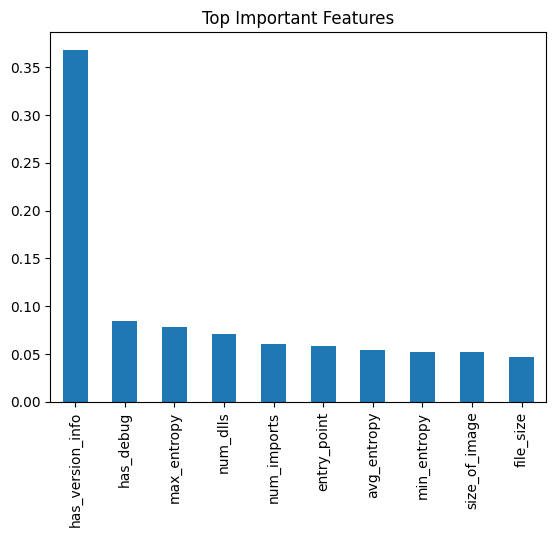

In [27]:
# ============================================
# CELL: Feature Importance Plot
# Purpose:
# Visualize most important features
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

importance = final_model.feature_importances_

feat = pd.Series(

    importance,

    index=FEATURE_COLUMNS

)

feat.sort_values(

    ascending=False

).head(10).plot(kind="bar")

plt.title("Top Important Features")

plt.show()

In [28]:
# ============================================
# CELL: Final Model Evaluation
# Purpose:
# Evaluate final RandomForest model
# ============================================

from sklearn.metrics import (

    accuracy_score,
    precision_score,
    recall_score,
    f1_score

)

y_pred = final_model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))

print("Precision:", precision_score(y_test, y_pred))

print("Recall   :", recall_score(y_test, y_pred))

print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.9727272727272728
Precision: 0.9855072463768116
Recall   : 0.951048951048951
F1 Score : 0.9679715302491103


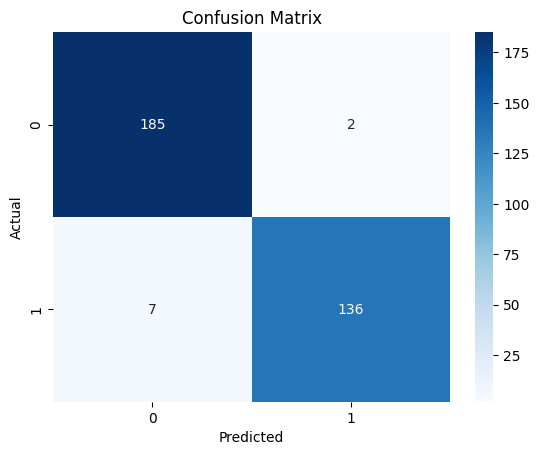

In [29]:
# ============================================
# CELL: Confusion Matrix
# Purpose:
# Visualize classification performance
# ============================================

from sklearn.metrics import confusion_matrix

import seaborn as sns

import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()